In [28]:
from pathlib import Path

import pandas as pd

import numpy as np
import matplotlib.pyplot as plt

# Data Columns
The data columns explanation is provided in the `notes.txt` file. We need to rename these columns using the mapping provided. First of all, we will check if all the information (columns) provided in the file are part of all the CSV data that we have

In [29]:
raw_data_folder = Path.cwd().parent/"data"/"raw"/"ligue1"

l1_data = {}

for file in raw_data_folder.glob("*.csv"):
    l1_data[file.stem] = pd.read_csv(file)

In [30]:
for name, df in l1_data.items():
    print(name, "has", len(df.columns), "columns")

F1_2122 has 105 columns
F1_2223 has 105 columns
F1_2324 has 105 columns
F1_2425 has 119 columns
F1_2526 has 131 columns


## Column mismatch
We can clearly see that the columns in the datasets are not the same, therefore we need to decide how to go forward

In [31]:
set(l1_data['F1_2122'].columns) == set(l1_data['F1_2223'].columns)

True

In [32]:
set(l1_data['F1_2122'].columns) == set(l1_data['F1_2526'].columns)

False

In [33]:
len(set(l1_data['F1_2122'].columns) - set(l1_data['F1_2526'].columns))

18

In [34]:
cols_sets = [set(df.columns) for df in l1_data.values()]
common_cols = set.intersection(*cols_sets[:4])
len(common_cols)

93

We notice that the first 3 datasets have the same set of columns, however we start to see a difference after 23-24 and it seems that there are removed not just added columns since the number of common columns is not equal to the number of columns of the smaller dataset

In [35]:
set(l1_data['F1_2122'].columns) - set(l1_data['F1_2425'].columns)


{'IWA',
 'IWCA',
 'IWCD',
 'IWCH',
 'IWD',
 'IWH',
 'VCA',
 'VCCA',
 'VCCD',
 'VCCH',
 'VCD',
 'VCH'}

In [36]:
set(l1_data['F1_2425'].columns) - set(l1_data['F1_2122'].columns)

{'1XBA',
 '1XBCA',
 '1XBCD',
 '1XBCH',
 '1XBD',
 '1XBH',
 'BFA',
 'BFCA',
 'BFCD',
 'BFCH',
 'BFD',
 'BFE<2.5',
 'BFE>2.5',
 'BFEA',
 'BFEAHA',
 'BFEAHH',
 'BFEC<2.5',
 'BFEC>2.5',
 'BFECA',
 'BFECAHA',
 'BFECAHH',
 'BFECD',
 'BFECH',
 'BFED',
 'BFEH',
 'BFH'}

## Interpretation
What we can do is set a specific set of bookmakers that is present for all datasets that we are going to use for the purpose of this project. Later we can check if those specific bookmakers are enough to represent the actual average or how good it approximates it.

An important thing to note here is that we also have **handicap** odds in our data. We are going to ignore the handicap odds and the goals difference odds for the first phase of the project.

In [37]:
common_cols = set.intersection(*cols_sets)

In [38]:
l1_data['F1_2324'][list(common_cols)]

,Avg>2.5,MaxC<2.5,AvgC<2.5,BWCD,AvgCD,B365CH,AvgCA,B365AHH,AvgH,BWCH,...,MaxAHH,Date,BWCA,AvgCAHH,HomeTeam,Max>2.5,B365H,Div,AvgC>2.5,B365C<2.5
0,1.88,2.06,1.93,3.30,3.40,2.45,2.86,1.88,2.57,2.45,...,1.94,11/08/2023,2.85,1.81,Nice,1.98,2.60,F1,1.89,1.98
1,1.78,2.07,1.97,3.60,3.69,1.95,4.03,1.92,1.70,1.95,...,1.94,12/08/2023,3.70,1.90,Marseille,1.85,1.70,F1,1.85,2.05
2,1.50,2.20,2.06,4.80,4.77,1.40,7.89,1.99,1.33,1.40,...,2.00,12/08/2023,7.75,1.92,Paris SG,1.53,1.33,F1,1.78,2.00
3,2.01,1.75,1.65,3.25,3.26,3.50,2.15,1.91,3.88,3.50,...,1.94,13/08/2023,2.15,2.00,Brest,2.08,4.00,F1,2.25,1.67
4,1.72,2.13,2.03,3.40,3.48,3.00,2.36,1.85,3.48,2.90,...,1.88,13/08/2023,2.35,1.82,Clermont,1.79,3.60,F1,1.80,2.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
301,1.41,3.07,2.95,5.75,5.73,1.30,8.81,1.88,1.41,1.31,...,1.93,19/05/2024,8.75,1.84,Lyon,1.44,1.42,F1,1.40,3.00
302,1.43,2.60,2.54,4.00,3.91,4.50,1.77,1.91,5.06,4.33,...,1.95,19/05/2024,1.73,1.87,Metz,1.48,5.50,F1,1.51,2.50
303,1.40,3.33,3.10,4.75,4.89,1.55,5.39,2.05,1.40,1.53,...,2.10,19/05/2024,5.25,1.83,Monaco,1.43,1.38,F1,1.37,3.00
304,1.60,2.60,2.53,3.60,3.63,3.10,2.30,2.07,2.79,2.95,...,2.11,19/05/2024,2.25,1.84,Reims,1.67,2.88,F1,1.51,2.50


Let's check the common bookmakers we have in these columns

In [39]:
non_bookies = [
    'Div',
    'Date',
    'Time',
    'HomeTeam',
    'AwayTeam',
    'FTHG',
    'FTAG',
    'FTR',
    'HTHG',
    'HTAG',
    'HTR',
    'HS',
    'AS',
    'HST',
    'AST',
    'HC',
    'AC',
    'HF',
    'AF',
    'HY',
    'AY',
    'HR',
    'AR',
]

In [40]:
set(non_bookies).issubset(common_cols)

True

In [41]:
common_cols - set(non_bookies)

{'AHCh',
 'AHh',
 'Avg<2.5',
 'Avg>2.5',
 'AvgA',
 'AvgAHA',
 'AvgAHH',
 'AvgC<2.5',
 'AvgC>2.5',
 'AvgCA',
 'AvgCAHA',
 'AvgCAHH',
 'AvgCD',
 'AvgCH',
 'AvgD',
 'AvgH',
 'B365<2.5',
 'B365>2.5',
 'B365A',
 'B365AHA',
 'B365AHH',
 'B365C<2.5',
 'B365C>2.5',
 'B365CA',
 'B365CAHA',
 'B365CAHH',
 'B365CD',
 'B365CH',
 'B365D',
 'B365H',
 'BWA',
 'BWCA',
 'BWCD',
 'BWCH',
 'BWD',
 'BWH',
 'Max<2.5',
 'Max>2.5',
 'MaxA',
 'MaxAHA',
 'MaxAHH',
 'MaxC<2.5',
 'MaxC>2.5',
 'MaxCA',
 'MaxCAHA',
 'MaxCAHH',
 'MaxCD',
 'MaxCH',
 'MaxD',
 'MaxH',
 'P<2.5',
 'P>2.5',
 'PAHA',
 'PAHH',
 'PC<2.5',
 'PC>2.5',
 'PCAHA',
 'PCAHH',
 'PSA',
 'PSCA',
 'PSCD',
 'PSCH',
 'PSD',
 'PSH'}

In [42]:
non_bookies_cols = {
    'Div' : "league_division",
    'Date' : "match_date",
    'Time' : "kick_off",
    'HomeTeam' : "home_team",
    'AwayTeam' : "away_team",
    'FTHG' : "full_time_home_goals",
    'FTAG' : "full_time_away_goals",
    'FTR' : "full_time_match_result",
    'HTHG' : "half_time_home_goals",
    'HTAG' : "half_time_away_goals",
    'HTR' : "half_time_match_result",
    'HS' : "home_shots",
    'AS' : "away_shots",
    'HST' : "home_shots_on_target",
    'AST' : "away_shots_on_target",
    'HC' : "home_corners",
    'AC' : "away_corners",
    'HF' : "home_fouls",
    'AF' : "away_fouls",
    'HY' : "home_yellow_cards",
    'AY' : "away_yellow_cards",
    'HR' : "home_red_cards",
    'AR' : "away_red_cards",
}

In [43]:
bookies = {
    "Avg" : "market_average",
    "Max" : "market_maximum",
    "B365" : "bet365",
    "BW" : "bet&win",
    "PS" : "pinnacle"
}

bookies_cols = {}

for col in common_cols - set(non_bookies):

    for abbreviation, bookmaker in bookies.items():

        if not col.startswith(abbreviation):
            continue

        remainder = col[len(abbreviation):]

        name = bookmaker

        if remainder.startswith("C"):
            name += "_closing"
            remainder = remainder[1:]

        if remainder == "H":
            name += "_home_odds"
        elif remainder == "D":
            name += "_draw_odds"
        elif remainder == "A":
            name += "_away_odds"
        else:
            continue

        bookies_cols[col] = name

In [44]:
bookies_cols

{'MaxH': 'market_maximum_home_odds',
 'BWCD': 'bet&win_closing_draw_odds',
 'AvgCH': 'market_average_closing_home_odds',
 'AvgCD': 'market_average_closing_draw_odds',
 'B365CD': 'bet365_closing_draw_odds',
 'B365D': 'bet365_draw_odds',
 'B365CH': 'bet365_closing_home_odds',
 'AvgCA': 'market_average_closing_away_odds',
 'PSA': 'pinnacle_away_odds',
 'B365CA': 'bet365_closing_away_odds',
 'AvgH': 'market_average_home_odds',
 'PSH': 'pinnacle_home_odds',
 'PSCD': 'pinnacle_closing_draw_odds',
 'BWH': 'bet&win_home_odds',
 'PSD': 'pinnacle_draw_odds',
 'BWCH': 'bet&win_closing_home_odds',
 'MaxCA': 'market_maximum_closing_away_odds',
 'BWCA': 'bet&win_closing_away_odds',
 'PSCA': 'pinnacle_closing_away_odds',
 'AvgA': 'market_average_away_odds',
 'MaxD': 'market_maximum_draw_odds',
 'MaxCD': 'market_maximum_closing_draw_odds',
 'B365H': 'bet365_home_odds',
 'PSCH': 'pinnacle_closing_home_odds',
 'BWA': 'bet&win_away_odds',
 'AvgD': 'market_average_draw_odds',
 'B365A': 'bet365_away_odds',

In [45]:
col_mapping = {
    **non_bookies_cols,
    **bookies_cols
}

In [46]:
col_mapping

{'Div': 'league_division',
 'Date': 'match_date',
 'Time': 'kick_off',
 'HomeTeam': 'home_team',
 'AwayTeam': 'away_team',
 'FTHG': 'full_time_home_goals',
 'FTAG': 'full_time_away_goals',
 'FTR': 'full_time_match_result',
 'HTHG': 'half_time_home_goals',
 'HTAG': 'half_time_away_goals',
 'HTR': 'half_time_match_result',
 'HS': 'home_shots',
 'AS': 'away_shots',
 'HST': 'home_shots_on_target',
 'AST': 'away_shots_on_target',
 'HC': 'home_corners',
 'AC': 'away_corners',
 'HF': 'home_fouls',
 'AF': 'away_fouls',
 'HY': 'home_yellow_cards',
 'AY': 'away_yellow_cards',
 'HR': 'home_red_cards',
 'AR': 'away_red_cards',
 'MaxH': 'market_maximum_home_odds',
 'BWCD': 'bet&win_closing_draw_odds',
 'AvgCH': 'market_average_closing_home_odds',
 'AvgCD': 'market_average_closing_draw_odds',
 'B365CD': 'bet365_closing_draw_odds',
 'B365D': 'bet365_draw_odds',
 'B365CH': 'bet365_closing_home_odds',
 'AvgCA': 'market_average_closing_away_odds',
 'PSA': 'pinnacle_away_odds',
 'B365CA': 'bet365_closing

In [47]:
len(common_cols)

87

In [48]:
len(col_mapping)

53

# Sanity Checks
We want to do a couple of checks to make sure that the mapping is happening as desired and there are no bugs in our system. We will divide the checks into 2 phases: before and after mapping.

## Phase 1: Before mapping
- Check common columns for all the datasets.
- Check what features exist that we don't want in our target schema.
- Is the schema defined available in all datasets?

## Phase 2: After mapping
- Did everything map like expected?
- Is there any unmapped columns?
- Is there any unwanted columns?

To do these checks, we are relying on `common_cols` which represents the common columns accross all datasets and `col_mapping` which contains the target schema.

In [49]:
## Phase 1

# common columns for all dataset
cols_sets = [set(df.columns) for df in l1_data.values()]
common_cols = set.intersection(*cols_sets)
print("There are", len(common_cols), "common columns accross all datasets.")

# target schema
print("\nFor the purpose of this project, we are going to use", len(col_mapping), "columns.")
print("These columns are the following:")
for col, name in col_mapping.items():
    print(col, name)
    
# Check extra features in datasets
print("\nChecking extra columns in datasets:")
for name, df in l1_data.items():
    extra_cols = set(df.columns) - set(col_mapping.keys())
    print(name,"has",len(extra_cols),"extra columns.")

# Check if the schema is in all datasets
print("\nChecking schema correctness in all datasets:")
for name, df in l1_data.items():
    schema = set(df.columns) & set(col_mapping.keys())
    print(name, str(set(col_mapping.keys()).issubset(df.columns)))

There are 87 common columns accross all datasets.

For the purpose of this project, we are going to use 53 columns.
These columns are the following:
Div league_division
Date match_date
Time kick_off
HomeTeam home_team
AwayTeam away_team
FTHG full_time_home_goals
FTAG full_time_away_goals
FTR full_time_match_result
HTHG half_time_home_goals
HTAG half_time_away_goals
HTR half_time_match_result
HS home_shots
AS away_shots
HST home_shots_on_target
AST away_shots_on_target
HC home_corners
AC away_corners
HF home_fouls
AF away_fouls
HY home_yellow_cards
AY away_yellow_cards
HR home_red_cards
AR away_red_cards
MaxH market_maximum_home_odds
BWCD bet&win_closing_draw_odds
AvgCH market_average_closing_home_odds
AvgCD market_average_closing_draw_odds
B365CD bet365_closing_draw_odds
B365D bet365_draw_odds
B365CH bet365_closing_home_odds
AvgCA market_average_closing_away_odds
PSA pinnacle_away_odds
B365CA bet365_closing_away_odds
AvgH market_average_home_odds
PSH pinnacle_home_odds
PSCD pinnacle_cl

In [50]:
## Phase 2
mapped_l1_data = {}

for name, df in l1_data.items():
    mapped_l1_data[name] = df.loc[:, df.columns.intersection(col_mapping.keys())].rename(columns=col_mapping)

In [51]:
# Did everything map like expected?
print("Checking if columns of the new datasets corresponds to the desired schema:")
for name, df in mapped_l1_data.items():
    print(name, "has", df.shape[1], "columns")
    print(name, str(set(df.columns) == set(col_mapping.values())))

Checking if columns of the new datasets corresponds to the desired schema:
F1_2122 has 53 columns
F1_2122 True
F1_2223 has 53 columns
F1_2223 True
F1_2324 has 53 columns
F1_2324 True
F1_2425 has 53 columns
F1_2425 True
F1_2526 has 53 columns
F1_2526 True


In [52]:
mapped_l1_data['F1_2122']

,league_division,match_date,kick_off,home_team,away_team,full_time_home_goals,full_time_away_goals,full_time_match_result,half_time_home_goals,half_time_away_goals,...,bet&win_closing_away_odds,pinnacle_closing_home_odds,pinnacle_closing_draw_odds,pinnacle_closing_away_odds,market_maximum_closing_home_odds,market_maximum_closing_draw_odds,market_maximum_closing_away_odds,market_average_closing_home_odds,market_average_closing_draw_odds,market_average_closing_away_odds
0,F1,06/08/2021,20:00,Monaco,Nantes,1,1,D,1,1,...,8.00,1.44,4.83,8.07,1.53,5.00,8.84,1.42,4.64,7.66
1,F1,07/08/2021,16:00,Lyon,Brest,1,1,D,0,1,...,8.25,1.37,5.55,8.59,1.42,5.75,9.00,1.36,5.40,8.04
2,F1,07/08/2021,20:00,Troyes,Paris SG,1,2,A,1,2,...,1.33,9.57,5.60,1.35,10.70,5.90,1.42,8.96,5.43,1.33
3,F1,08/08/2021,12:00,Rennes,Lens,1,1,D,1,1,...,4.00,1.93,3.68,4.32,1.99,3.81,4.43,1.91,3.56,4.09
4,F1,08/08/2021,14:00,Bordeaux,Clermont,0,2,A,0,0,...,2.95,2.69,3.22,2.95,2.76,3.42,3.19,2.58,3.18,2.88
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
375,F1,21/05/2022,20:00,Lorient,Troyes,1,1,D,0,1,...,3.20,2.21,3.63,3.33,2.28,3.70,3.46,2.22,3.53,3.22
376,F1,21/05/2022,20:00,Marseille,Strasbourg,4,0,H,1,0,...,3.50,2.21,3.35,3.70,2.28,3.36,3.86,2.19,3.27,3.56
377,F1,21/05/2022,20:00,Nantes,St Etienne,1,1,D,1,0,...,2.75,2.52,3.60,2.88,2.65,3.81,3.00,2.45,3.55,2.80
378,F1,21/05/2022,20:00,Paris SG,Metz,5,0,H,3,0,...,19.00,1.14,10.12,17.90,1.20,12.40,25.00,1.13,9.87,17.66


# Data Quality
We are going to be using `mapped_l1_data` moving forward

In [53]:
for name, df in mapped_l1_data.items():
    print(f"\n{name} has {df.shape[0]} rows and {df.shape[1]} columns")
    print(df.isna().sum().sort_values(ascending=False).head(10))


F1_2122 has 380 rows and 53 columns
bet&win_draw_odds         1
bet&win_away_odds         1
bet&win_home_odds         1
match_date                0
league_division           0
full_time_home_goals      0
full_time_away_goals      0
full_time_match_result    0
half_time_home_goals      0
half_time_away_goals      0
dtype: int64

F1_2223 has 380 rows and 53 columns
league_division           0
match_date                0
kick_off                  0
home_team                 0
away_team                 0
full_time_home_goals      0
full_time_away_goals      0
full_time_match_result    0
half_time_home_goals      0
half_time_away_goals      0
dtype: int64

F1_2324 has 306 rows and 53 columns
bet&win_closing_away_odds    9
bet&win_closing_draw_odds    9
bet&win_home_odds            9
bet&win_away_odds            9
bet&win_draw_odds            9
bet&win_closing_home_odds    9
full_time_away_goals         0
full_time_home_goals         0
half_time_home_goals         0
half_time_away_goals    

In [54]:
df2526 = mapped_l1_data['F1_2526']

In [55]:
df2526[df2526['pinnacle_home_odds'].isna()][non_bookies_cols.values()]

,league_division,match_date,kick_off,home_team,away_team,full_time_home_goals,full_time_away_goals,full_time_match_result,half_time_home_goals,half_time_away_goals,...,home_shots_on_target,away_shots_on_target,home_corners,away_corners,home_fouls,away_fouls,home_yellow_cards,away_yellow_cards,home_red_cards,away_red_cards
153,F1,16/01/2026,18:00,Monaco,Lorient,1,3,A,0,0,...,7,4,4,3,16,9,1,0,0,0
154,F1,16/01/2026,20:00,Paris SG,Lille,3,0,H,1,0,...,7,4,4,2,14,6,0,1,0,0
155,F1,17/01/2026,16:00,Lens,Auxerre,1,0,H,0,0,...,7,0,1,5,19,20,2,5,0,0
156,F1,17/01/2026,18:00,Toulouse,Nice,5,1,H,2,0,...,10,6,6,7,12,17,1,2,0,0
157,F1,17/01/2026,20:05,Angers,Marseille,2,5,A,1,4,...,3,11,6,2,9,8,1,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
300,F1,17/05/2026,20:00,Lyon,Lens,0,4,A,0,3,...,4,4,20,8,10,11,1,4,0,0
301,F1,17/05/2026,20:00,Marseille,Rennes,3,1,H,2,0,...,11,6,4,11,11,10,3,1,0,0
302,F1,17/05/2026,20:00,Nice,Metz,0,0,D,0,0,...,4,4,10,4,11,15,2,1,0,0
303,F1,17/05/2026,20:00,Paris FC,Paris SG,2,1,H,0,0,...,9,2,3,3,8,9,2,1,0,0


In [56]:
df2526[df2526['pinnacle_home_odds'].isna()]['match_date'].describe()

count            152
unique            49
top       10/05/2026
freq               8
Name: match_date, dtype: object

In [57]:
df2526[df2526['pinnacle_home_odds'].notna()]['match_date'].describe()

count            153
unique            49
top       29/10/2025
freq               9
Name: match_date, dtype: object

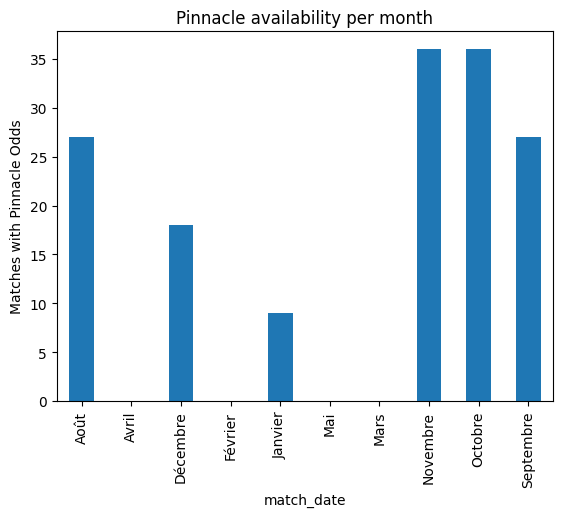

In [58]:
monthly = df2526.groupby(
    pd.to_datetime(df2526['match_date'], format="%d/%m/%Y").dt.month_name(locale="French")
)['pinnacle_home_odds'].count()

monthly.plot(kind="bar")
plt.ylabel("Matches with Pinnacle Odds")
plt.title("Pinnacle availability per month")
plt.show()

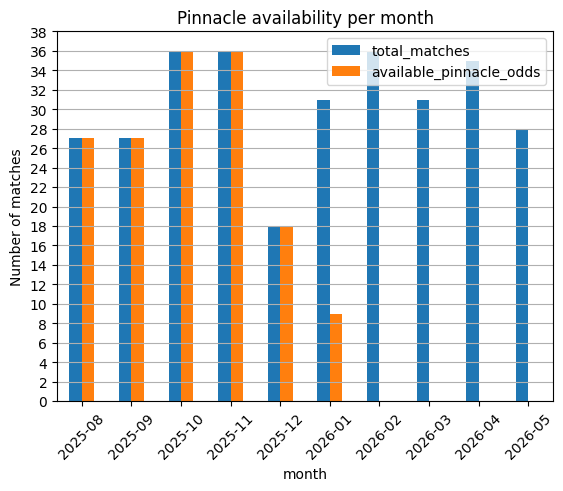

In [59]:
df = df2526.copy()

df["match_date"] = pd.to_datetime(df["match_date"], dayfirst=True)

df["month"] = df["match_date"].dt.to_period("M")

df["has_pinnacle_odds"] = df["pinnacle_home_odds"].notna()

monthly_total = df.groupby("month").agg(
    total_matches=("match_date", "size"),
    available_pinnacle_odds=("has_pinnacle_odds", "sum")
)

monthly_total_plot = monthly_total.copy()
monthly_total_plot.index = monthly_total_plot.index.astype(str)

monthly_total_plot.plot(kind="bar")

plt.yticks(np.arange(0, 40, 2))
plt.ylabel("Number of matches")
plt.title("Pinnacle availability per month")
plt.grid(axis="y")

plt.xticks(rotation=45)

plt.show()

In [60]:
monthly_total.sum()

total_matches              305
available_pinnacle_odds    153
dtype: int64

## Inconsistencies
We can clearly see that we have a coverage issue regarding our data. Pinnacle stopped reporting odds after january which may be an API issue for example. What we are gonna do is check all the reportings to all of our fixed bookmakers compared to the number of matches

In [61]:
bookies

{'Avg': 'market_average',
 'Max': 'market_maximum',
 'B365': 'bet365',
 'BW': 'bet&win',
 'PS': 'pinnacle'}

In [62]:
def coverage_plot(df: pd.DataFrame, bookmakers: dict):
    plot_df = df.copy()
    
    plot_df['match_date'] = pd.to_datetime(
        plot_df['match_date'],
        dayfirst = True
    )
    plot_df['month'] = plot_df['match_date'].dt.to_period("M")
    
    for bookie in bookmakers.values():
        col_name = bookie + "_home_odds"
        plot_df[f"has_{bookie}"] = plot_df[col_name].notna()
        
    agg_dict = {
        "match_date" : "size"
    }
    for bookie in bookmakers.values():
        agg_dict[f"has_{bookie}"] = "sum"
        
    monthly_totals = plot_df.groupby("month").agg(agg_dict)
    monthly_totals = monthly_totals.rename(
        columns = {"match_date" : "total_matches"}
    )
    
    return monthly_totals

In [63]:
monthly_total.max()['total_matches']

np.int64(36)

Coverage for F1_2122


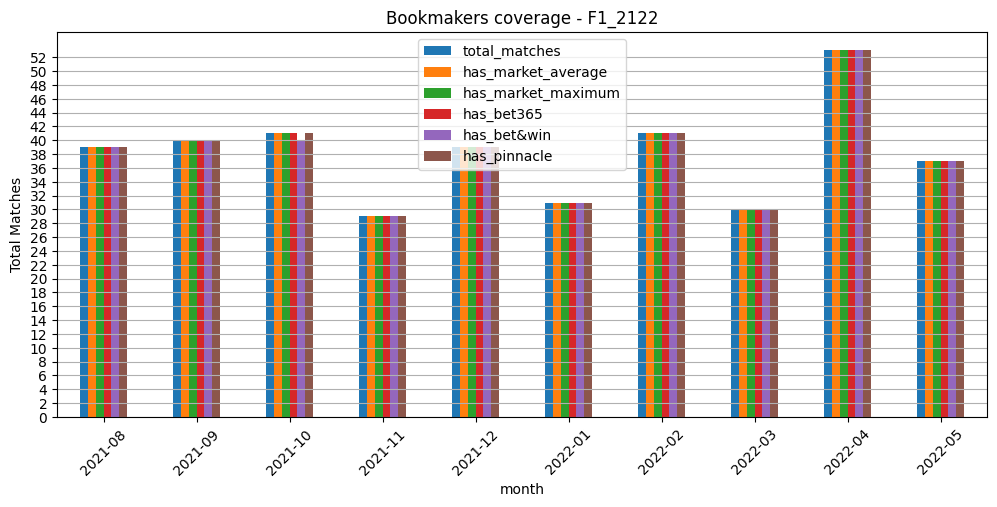

Coverage for F1_2223


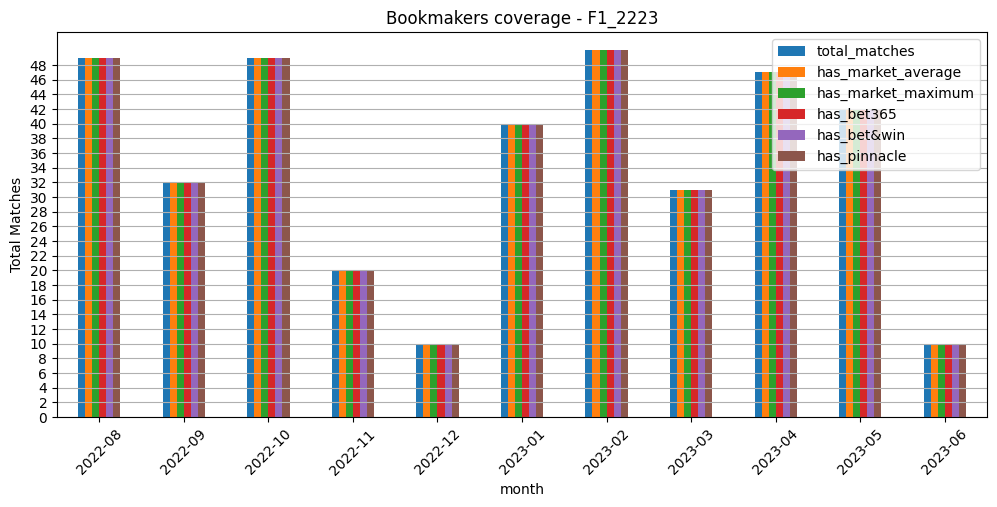

Coverage for F1_2324


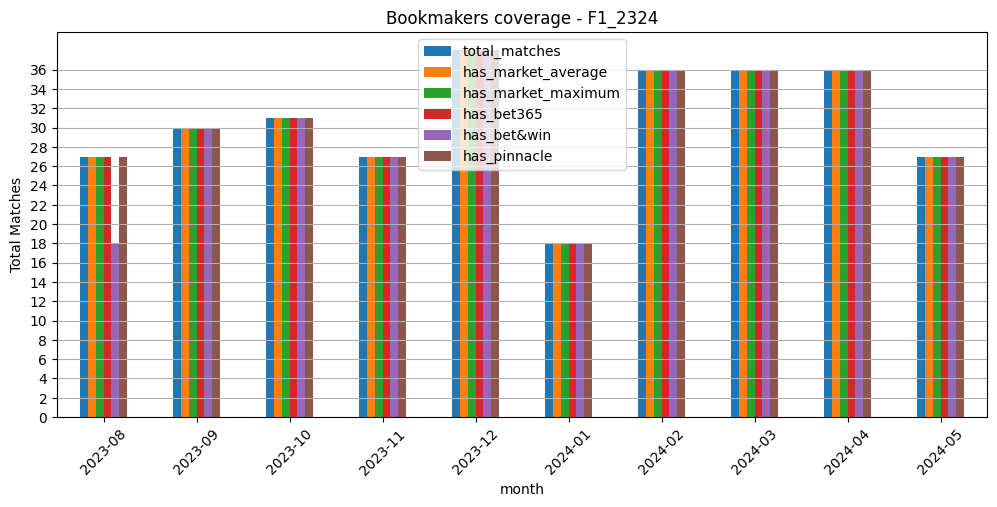

Coverage for F1_2425


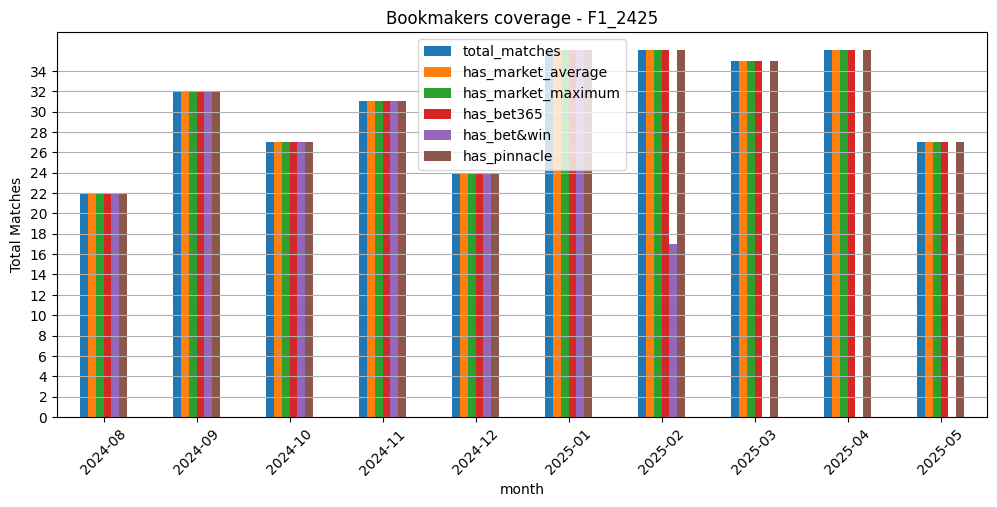

Coverage for F1_2526


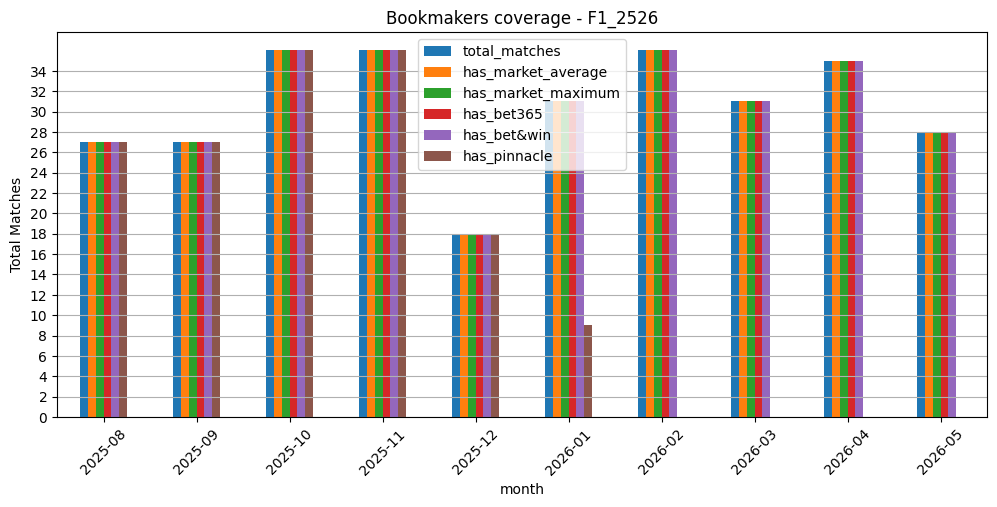

In [64]:
for name, df in mapped_l1_data.items():

    print(f"Coverage for {name}")

    monthly_totals = coverage_plot(df, bookies)

    fig, ax = plt.subplots(figsize=(12, 5))

    monthly_totals.plot(kind="bar", ax=ax)

    ax.set_title(f"Bookmakers coverage - {name}")
    ax.set_ylabel("Total Matches")
    ax.grid(axis="y")

    plt.yticks(np.arange(0,monthly_totals.max()['total_matches'],2))
    plt.xticks(rotation=45)
    plt.show()

## Value Range Check
Our odds should:
- always be positive
- no 0 values
- no insane values like 1000
- greater than 1

In [65]:
bookies

{'Avg': 'market_average',
 'Max': 'market_maximum',
 'B365': 'bet365',
 'BW': 'bet&win',
 'PS': 'pinnacle'}

Value range check for F1_2122


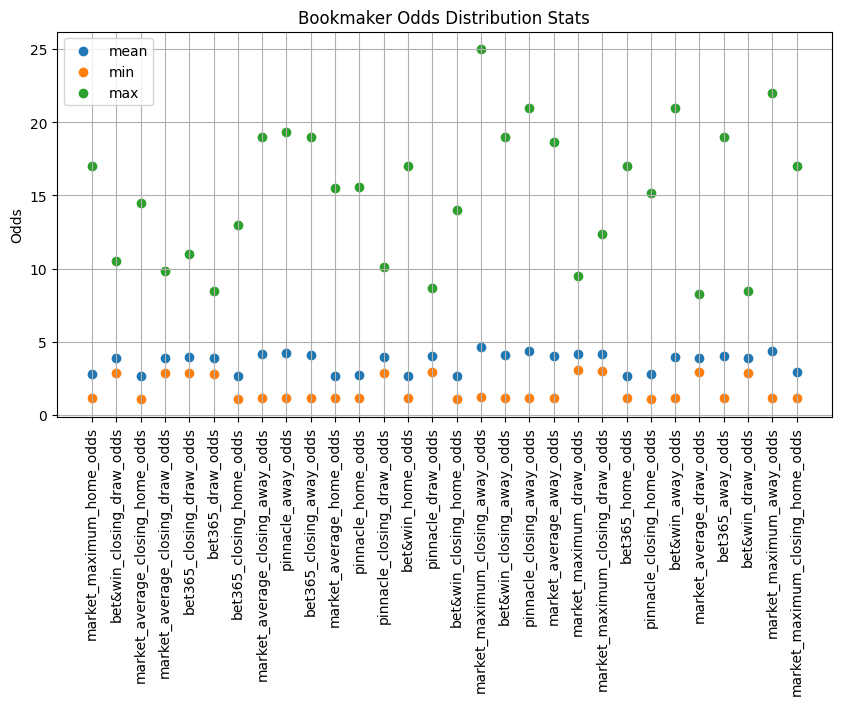

Value range check for F1_2223


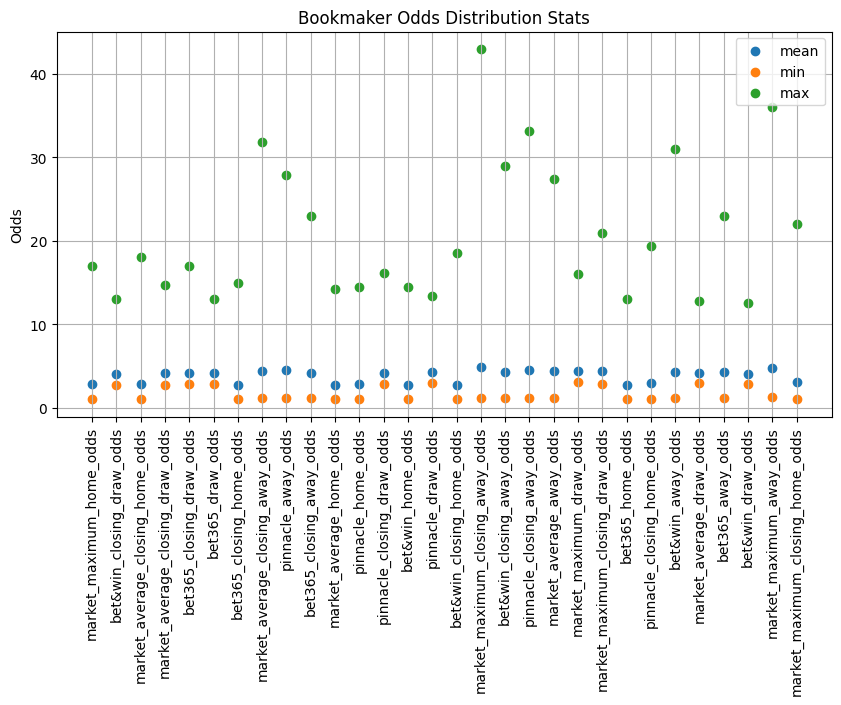

Value range check for F1_2324


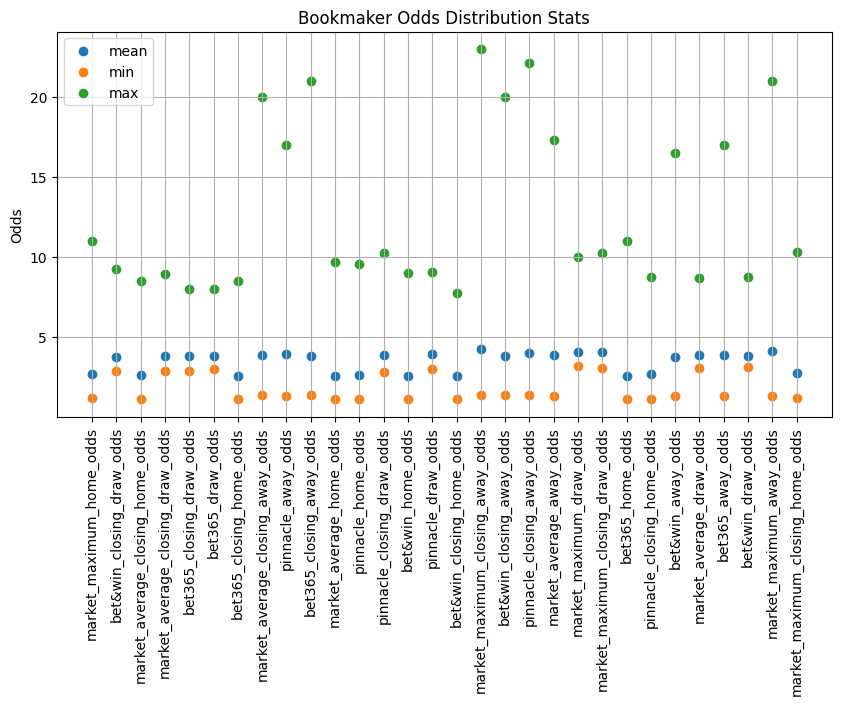

Value range check for F1_2425


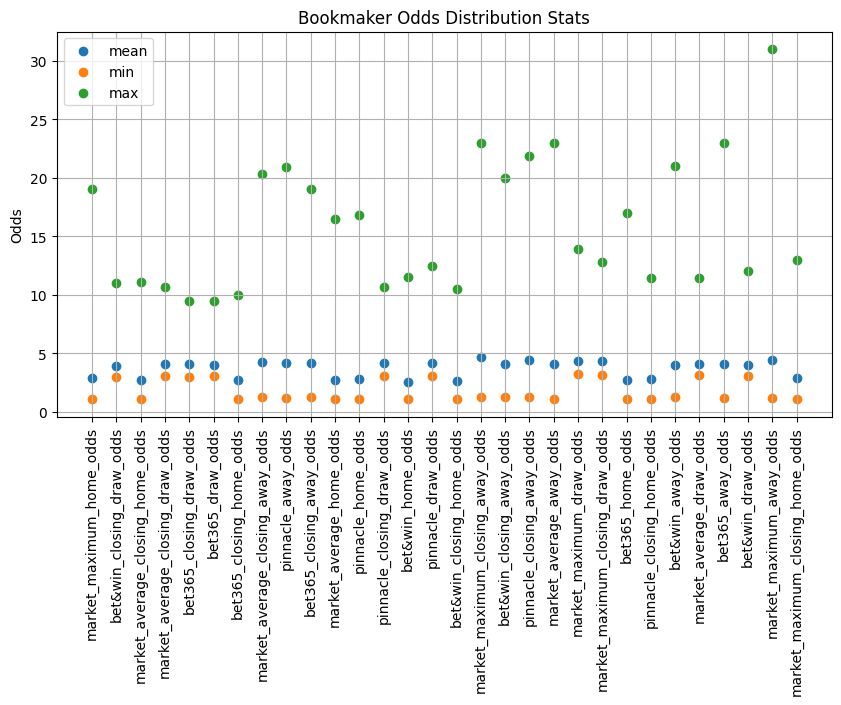

Value range check for F1_2526


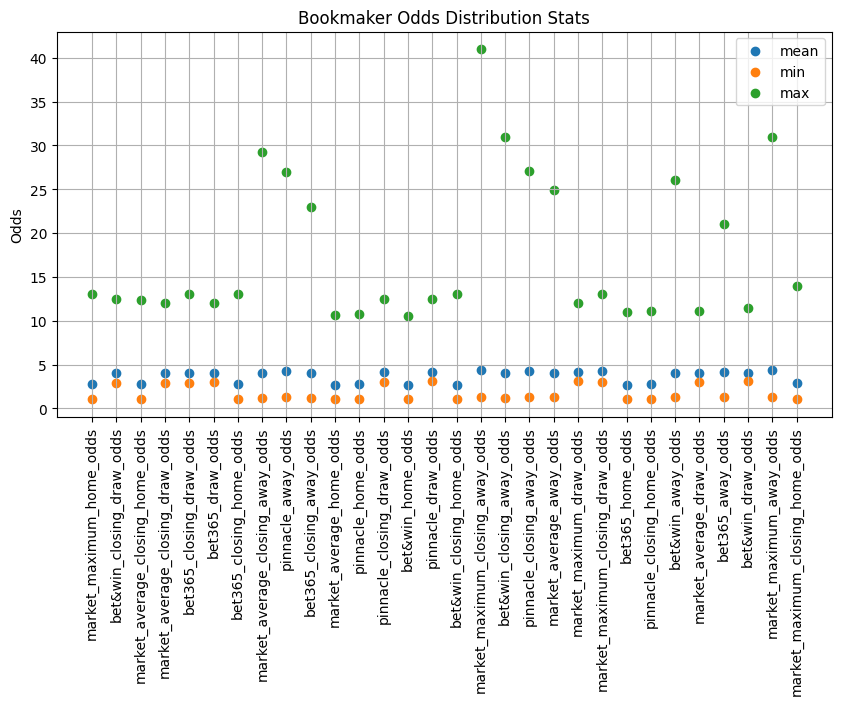

In [66]:
for name, df in mapped_l1_data.items():
    print(f"Value range check for {name}")
    interesting_values = df[list(bookies_cols.values())].describe()
    
    mean_odds = interesting_values.loc['mean']
    min_odds = interesting_values.loc['min']
    max_odds = interesting_values.loc['max']
    
    stats_df = pd.DataFrame({
        "mean": mean_odds,
        "min": min_odds,
        "max": max_odds
    }).reset_index().rename(columns={"index": "bookie"})
    
    plot_df = stats_df.melt(
        id_vars="bookie",
        var_name="metric",
        value_name="value"
    )
    
    plt.figure(figsize=(10,5))

    for metric in plot_df["metric"].unique():
        subset = plot_df[plot_df["metric"] == metric]
        plt.scatter(subset["bookie"], subset["value"], label=metric)

    plt.title("Bookmaker Odds Distribution Stats")
    plt.ylabel("Odds")
    plt.xticks(rotation=90)
    plt.legend()
    plt.grid()
    plt.show()

In [77]:
for name, df in mapped_l1_data.items():
    print((df[list(bookies_cols.values())] < 1).any().any())
    print((df[list(bookies_cols.values())] > 100).any().any())
    print((1/df[list(bookies_cols.values())] > 1).any().any())
    print((df['full_time_home_goals'] < 0).any().any())
    df["calculated_result"] = np.where(
        df["full_time_home_goals"] > df["full_time_away_goals"], "H",
        np.where(df["full_time_home_goals"] < df["full_time_away_goals"], "A", "D")
    )

    df[df["calculated_result"] != df["full_time_match_result"]]
    
    print(
        f"{name}: {df.duplicated().sum()} exact duplicates"
    )
    match_key = [
        "match_date",
        "home_team",
        "away_team"
    ]
    print(df.duplicated(subset=match_key).sum())

    

False
False
False
False
F1_2122: 0 exact duplicates
0
False
False
False
False
F1_2223: 0 exact duplicates
0
False
False
False
False
F1_2324: 0 exact duplicates
0
False
False
False
False
F1_2425: 0 exact duplicates
0
False
False
False
False
F1_2526: 0 exact duplicates
0


## Data Validity checks

### League Size
- How many unique teams participate in each season?
- Is the number consistent on all seasons?

In [89]:
mapped_l1_data['F1_2526']['home_team'].unique()

<ArrowStringArray>
[    'Rennes',       'Lens',     'Monaco',       'Nice',      'Brest',
     'Angers',    'Auxerre',       'Metz',     'Nantes',   'Paris SG',
  'Marseille',       'Lyon',    'Lorient',   'Le Havre', 'Strasbourg',
   'Toulouse',      'Lille',   'Paris FC']
Length: 18, dtype: str

In [92]:
set(mapped_l1_data['F1_2526']['home_team'].unique()) == set(mapped_l1_data['F1_2526']['away_team'].unique())

True

In [91]:
set(mapped_l1_data['F1_2526']['home_team'].unique()) == set(mapped_l1_data['F1_2122']['away_team'].unique())

False

We notice that we have 18 unique teams for 25/26 seaoson while it is not the case for 21/22 for example

In [94]:
for name, df in mapped_l1_data.items():
    print(f"\n{name} has {len(df['home_team'].unique())}")
    home_vs_away = set(df['home_team'].unique()) == set(df['away_team'].unique())
    if home_vs_away:
        print("Home and away teams are consistent")
    else:
        print("WARNING: inconsistencies between home and away teams")


F1_2122 has 20
Home and away teams are consistent

F1_2223 has 20
Home and away teams are consistent

F1_2324 has 18
Home and away teams are consistent

F1_2425 has 18
Home and away teams are consistent

F1_2526 has 18
Home and away teams are consistent


In [95]:
set(mapped_l1_data['F1_2122']['home_team'].unique()) - set(mapped_l1_data['F1_2526']['home_team'].unique())

{'Bordeaux', 'Clermont', 'Montpellier', 'Reims', 'St Etienne', 'Troyes'}

In [96]:
set(mapped_l1_data['F1_2425']['home_team'].unique()) == set(mapped_l1_data['F1_2526']['home_team'].unique())

False

In [97]:
set(mapped_l1_data['F1_2425']['home_team'].unique()) - set(mapped_l1_data['F1_2526']['home_team'].unique())


{'Montpellier', 'Reims', 'St Etienne'}

In [98]:
mapped_l1_data['F1_2526'].loc[mapped_l1_data['F1_2526']['home_team'] == 'Bordeaux']

,league_division,match_date,kick_off,home_team,away_team,full_time_home_goals,full_time_away_goals,full_time_match_result,half_time_home_goals,half_time_away_goals,...,pinnacle_closing_home_odds,pinnacle_closing_draw_odds,pinnacle_closing_away_odds,market_maximum_closing_home_odds,market_maximum_closing_draw_odds,market_maximum_closing_away_odds,market_average_closing_home_odds,market_average_closing_draw_odds,market_average_closing_away_odds,calculated_result


The teams keeps changing from one season to another since there are minimum two teams that get demoted and two other that get promoted for the league

In [101]:
set(mapped_l1_data['F1_2425']['home_team'].unique())

{'Angers',
 'Auxerre',
 'Brest',
 'Le Havre',
 'Lens',
 'Lille',
 'Lyon',
 'Marseille',
 'Monaco',
 'Montpellier',
 'Nantes',
 'Nice',
 'Paris SG',
 'Reims',
 'Rennes',
 'St Etienne',
 'Strasbourg',
 'Toulouse'}

In [102]:
set(mapped_l1_data['F1_2526']['home_team'].unique())

{'Angers',
 'Auxerre',
 'Brest',
 'Le Havre',
 'Lens',
 'Lille',
 'Lorient',
 'Lyon',
 'Marseille',
 'Metz',
 'Monaco',
 'Nantes',
 'Nice',
 'Paris FC',
 'Paris SG',
 'Rennes',
 'Strasbourg',
 'Toulouse'}